In [6]:
import numpy as np 
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
dataset = pl.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
print(dataset.head())

shape: (5, 12)
┌─────────────┬──────────┬────────┬───────────────────┬───┬───────────┬─────────┬───────┬──────────┐
│ PassengerId ┆ Survived ┆ Pclass ┆ Name              ┆ … ┆ Ticket    ┆ Fare    ┆ Cabin ┆ Embarked │
│ ---         ┆ ---      ┆ ---    ┆ ---               ┆   ┆ ---       ┆ ---     ┆ ---   ┆ ---      │
│ i64         ┆ i64      ┆ i64    ┆ str               ┆   ┆ str       ┆ f64     ┆ str   ┆ str      │
╞═════════════╪══════════╪════════╪═══════════════════╪═══╪═══════════╪═════════╪═══════╪══════════╡
│ 1           ┆ 0        ┆ 3      ┆ Braund, Mr. Owen  ┆ … ┆ A/5 21171 ┆ 7.25    ┆ null  ┆ S        │
│             ┆          ┆        ┆ Harris            ┆   ┆           ┆         ┆       ┆          │
│ 2           ┆ 1        ┆ 1      ┆ Cumings, Mrs.     ┆ … ┆ PC 17599  ┆ 71.2833 ┆ C85   ┆ C        │
│             ┆          ┆        ┆ John Bradley (Fl… ┆   ┆           ┆         ┆       ┆          │
│ 3           ┆ 1        ┆ 3      ┆ Heikkinen, Miss.  ┆ … ┆ STON/O2.  ┆ 7.92

              precision    recall  f1-score   support

           0       0.82      0.90      0.85       105
           1       0.83      0.72      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



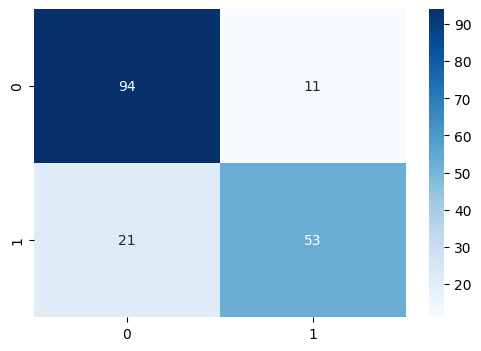

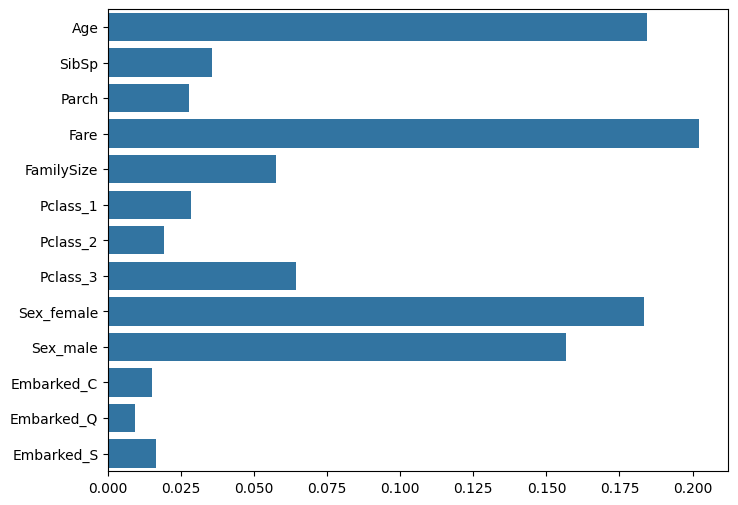

In [5]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix

df = pl.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

df = df.with_columns([
    (pl.col("SibSp") + pl.col("Parch") + 1).alias("FamilySize"),
    pl.col("Age").fill_null(df["Age"].median()),
    pl.col("Embarked").fill_null("S")
])

df = df.drop(["PassengerId", "Name", "Ticket", "Cabin"])

X = df.drop("Survived").to_pandas()
y = df["Survived"].to_numpy()

num_features = ["Age", "SibSp", "Parch", "Fare", "FamilySize"]
cat_features = ["Pclass", "Sex", "Embarked"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline.fit(X_train, y_train)
preds = pipeline.predict(X_test)

print(classification_report(y_test, preds))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap="Blues")
plt.show()

feature_names = (
    num_features + 
    list(pipeline.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(cat_features))
)
importances = pipeline.named_steps["clf"].feature_importances_

plt.figure(figsize=(8, 6))
sns.barplot(x=importances, y=feature_names)
plt.show()